# Overlap of DEGs
For both phase 1 oysters and phase 2 oysters, I ran DESeq but isolated the effects of phase 1 (and 2) temperature and DO treatments (so identified DEGs for phase 2 warm vs. ambient, ignoring the effects of phase 1 and phase 2 DO treamtents). I'm now curious if there is overlap between the DEGs I've identified in phase 1 and phase 2.

doing this with the results from using the new reference genome

## 0. load libraries

In [2]:
library(tidyverse)
library(UpSetR)
library(ggvenn)

## 1. load CSVs

#### phase 1 oysters

In [3]:
p1_DO <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/hypoxic_v_normoxic.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p1_DO) # 34 DEGs

[1] 34  8

In [5]:
p1_temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/warm_v_ambient.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p1_temp) # 84 DEGs

[1] 84  8

#### phase 2 oysters

In [6]:
p2_p1.DO <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/isolated_treatments/p1_DO.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p2_p1.DO) # 55 DEGs

[1]  55 102

In [7]:
p2_p1.temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/isolated_treatments/p1_temp.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p2_p1.temp) # 36 DEGs

[1]  36 102

In [8]:
p2_p2.DO <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/isolated_treatments/p2_DO.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p2_p2.DO) # 51 DEGs

[1]  51 102

In [10]:
p2_p2.temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/isolated_treatments/p2_temp.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p2_p2.temp) # 160 DEGs

[1] 160 102

## 2. UpSet Plots

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”


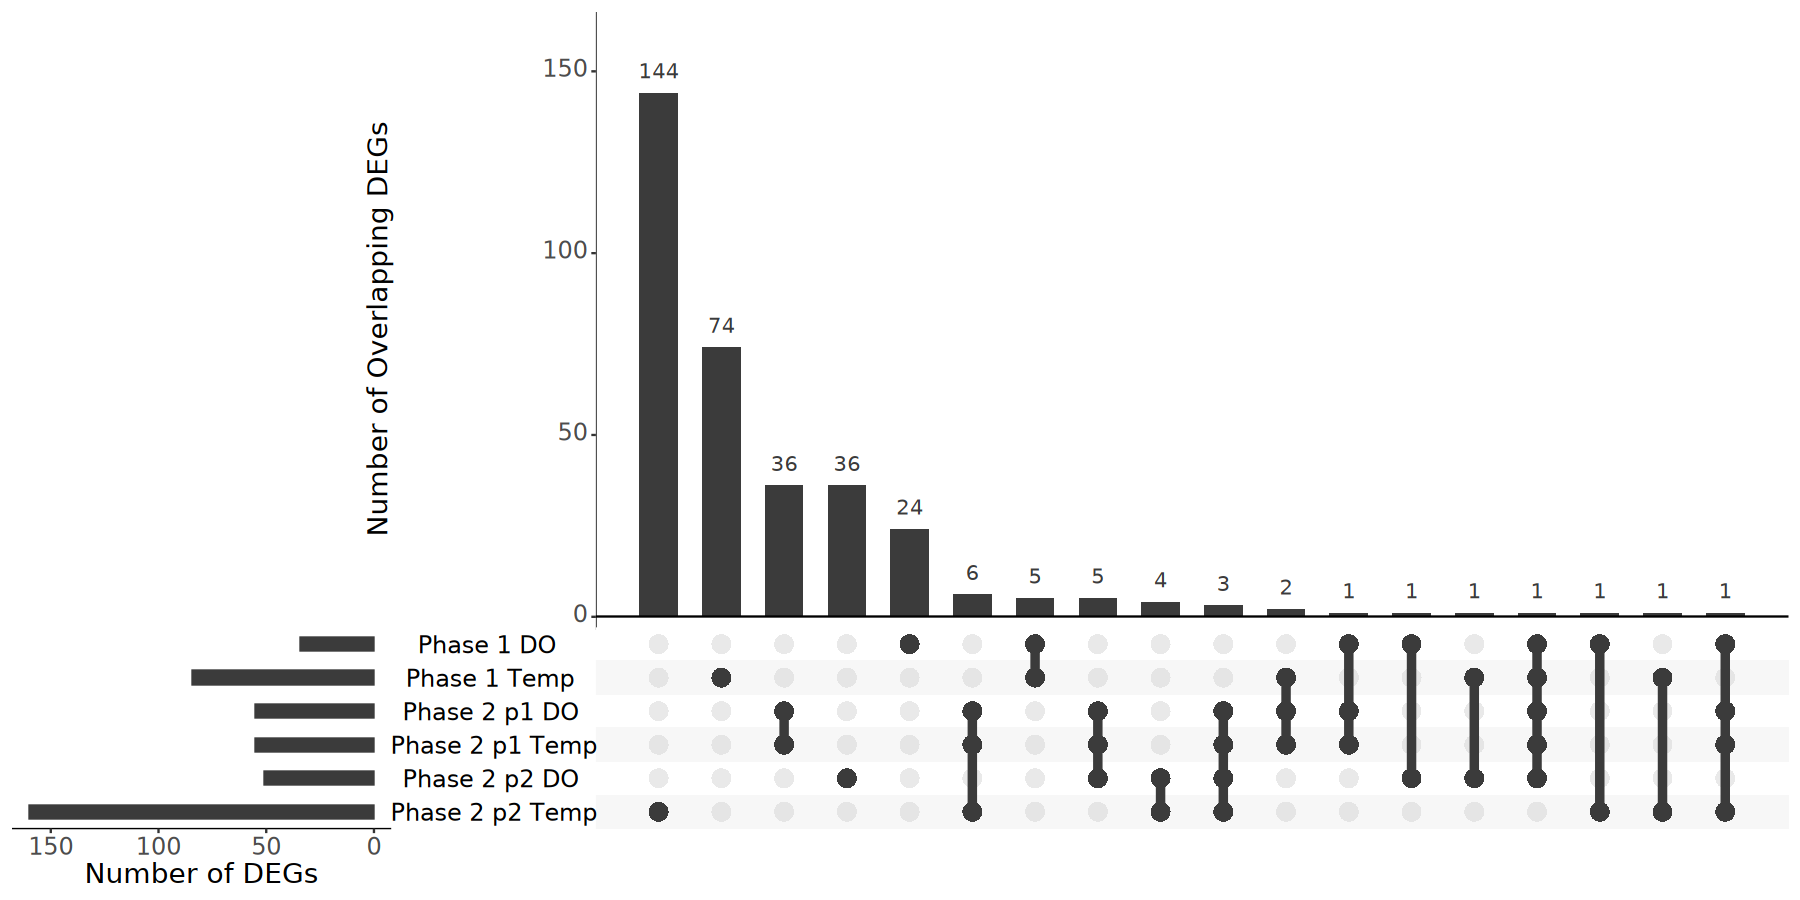

In [11]:
options(repr.plot.width = 15, repr.plot.height = 7.5)

# make list for input into upset
DEGs = list('Phase 1 DO' = p1_DO$X,
            'Phase 1 Temp' = p1_temp$X,
            'Phase 2 p1 DO' = p2_p1.DO$Gene,
            'Phase 2 p1 Temp' = p2_p1.DO$Gene,
            'Phase 2 p2 DO' = p2_p2.DO$Gene,
            'Phase 2 p2 Temp' = p2_p2.temp$Gene)

# plot
upset(
  fromList(DEGs),
    sets = rev(names(DEGs)),   # enforce order
  keep.order = TRUE,
  order.by = "freq",
  nsets = 6,
  point.size = 5,
  line.size = 2,
  mainbar.y.label = "Number of Overlapping DEGs",
  sets.x.label = "Number of DEGs",
  text.scale = c(2, 2, 2, 2, 2, 2)
)

- 36 DEGs are shared in phase 2 oysters phase 1 treatments (so general response to early stressors? "memory" genes?)
- there are not many DEGs that are shared between phase 1 and phase 2 oysters - most expression is unique to that time period and stressor
- 1 gene shared from phase 1 DO and phase 2 oysters phase 2 DO - general DO resposne?
- there's a few DEGs that are shared between phase 1 oysters DO and phase 2 oysters phase 1 DO (and others) - could be lasting expression from early life DO? 
- 3 DEGs that is shared in all of the Phase 2 oysters

I think it's hard for me to reconcile these comparisons because in each one, you're ignoring some other treatments (which is okay?) - meaning, when looking at phase 2 oysters phase 1 DO treatment, you're lumping anything that experienced phase 1 hypoxia together, regardless of phase 2 exposure (H and B for phase 1, anything for phase 2) and vice versa

## 3. venn diagram of isolated treatments
using [ggvenn](https://github.com/yanlinlin82/ggvenn)

#### temperature

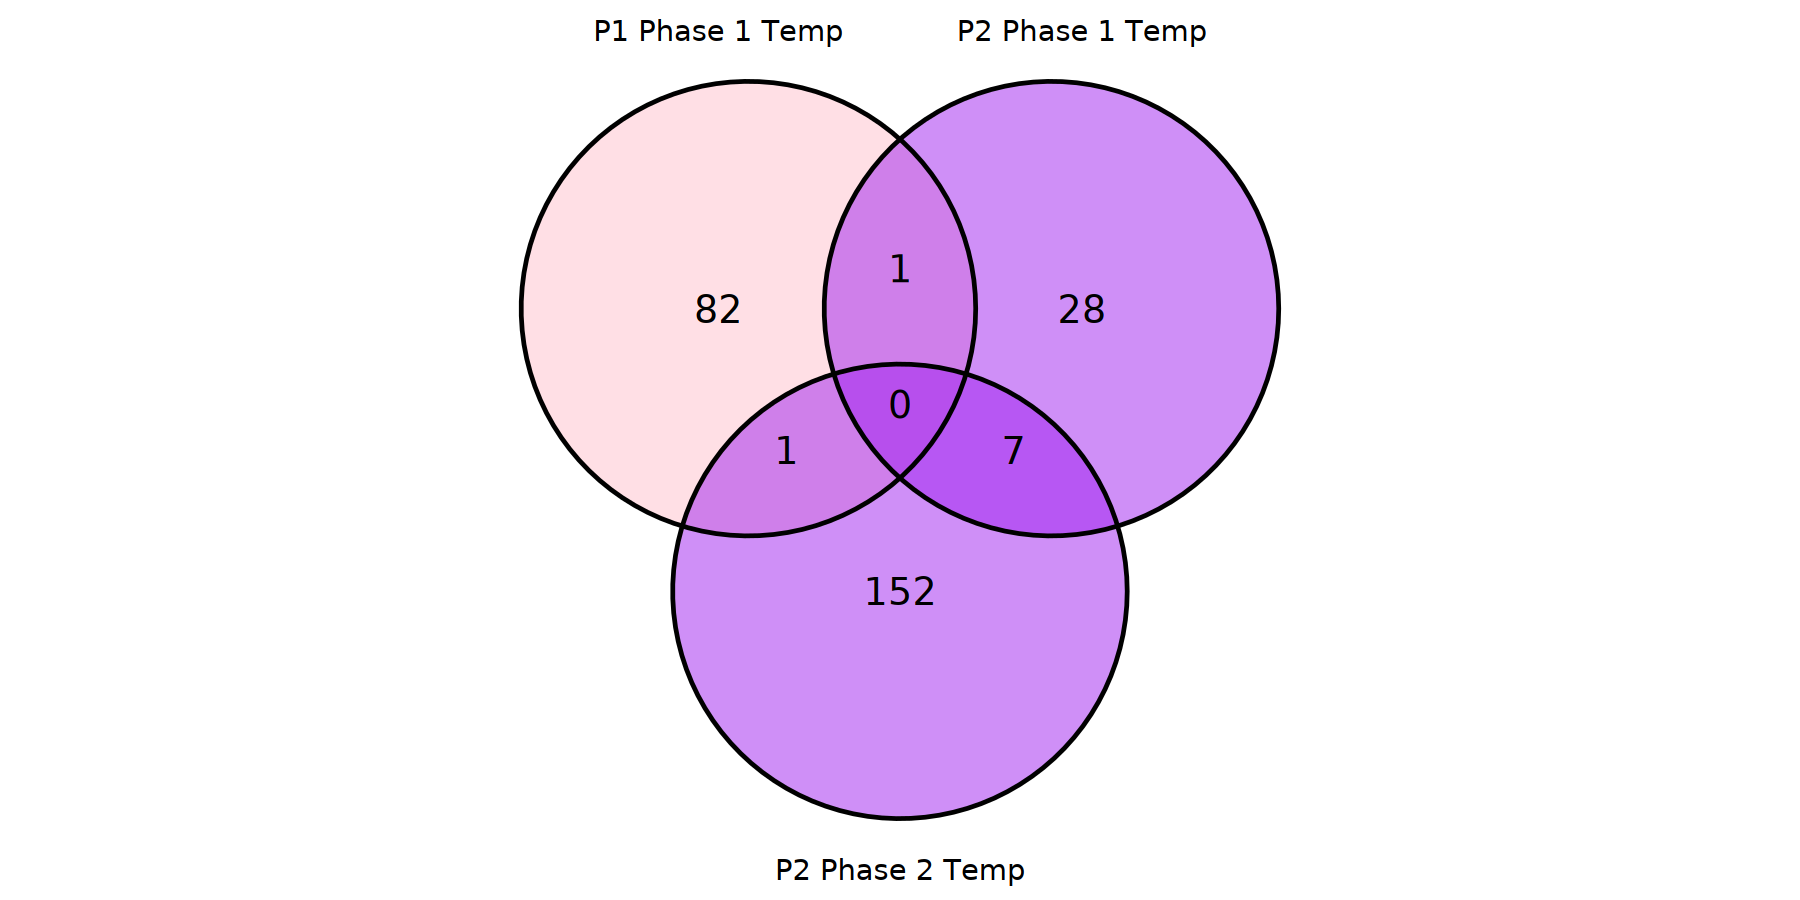

In [12]:
temp = list('P1 Phase 1 Temp' = p1_temp$X,
            'P2 Phase 1 Temp' = p2_p1.temp$Gene,
            'P2 Phase 2 Temp' = p2_p2.temp$Gene)

ggvenn(temp,
      text_size = 8,
       fill_color = c('pink', 'purple', 'purple'),
      show_percentage = FALSE)

purple = phase 2 oysters, pink = phase 1 oysters

**observations**:
- as expected, most DEGs are unique to that comparison (so timing and age of oyster plays a role in the stress response)
    - Phase 2 late temp stress results in the highest number of DEGs, while Phase 2 early temp stress results in the lowest number (evidence of carryover effects, but diminished response as time progresses/another stressor is experienced - which makes sense since GE tends to be more short-term)
- no shared DEGs between all 3 temp groups (so no constitutive expression?)
- 2 shared between phase 1 oysters and phase 2 oysters - 1 with phase 2 oysters late and 1 with phase 2 oysters early
- 7 shared DEGs shared between phase 2 oysters (carryover effects??) 

#### dissolved oxygen

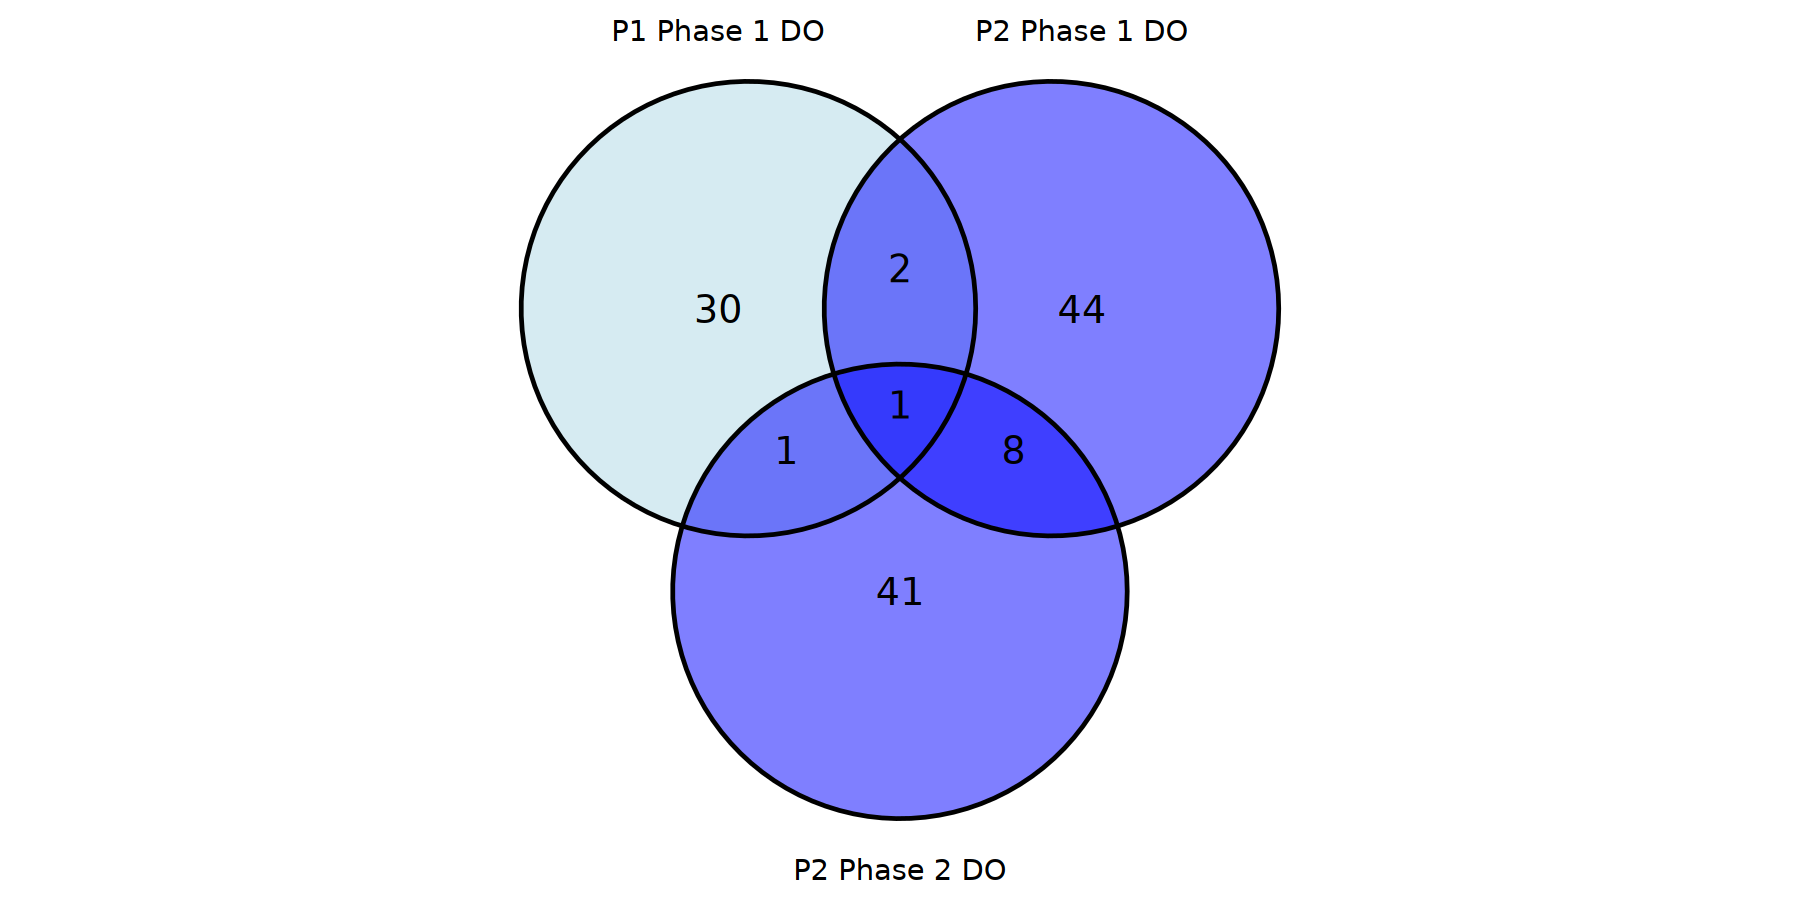

In [14]:
do = list('P1 Phase 1 DO' = p1_DO$X,
            'P2 Phase 1 DO' = p2_p1.DO$Gene,
            'P2 Phase 2 DO' = p2_p2.DO$Gene)

ggvenn(do,
      text_size = 8,
       fill_color = c('lightblue', 'blue', 'blue'),
      show_percentage = FALSE)

light blue = phase 1 oysters, dark blue = phase 2 oysters

**observations**:
- again, most DEGs are unique to that comparison (but we see roughly the same number of DEGs in all the comparisons - not sure what that means yet)
- 1 shared DEGs between all 3 DO groups (constitutive expression?)
- 2 shared between phase 1 and phase 2 oysters - 1 with phase 2 oysters late and 1 with phase 2 oysters early
- 8 shared between phase 2 oysters

### overall:
As a reminder, these DEGs were identified by isolating the treatments/ignoring the effects of other things - so for phase 2 oysters, DEGs are for phase 1 warm vs. ambient (ignoring the phase 1 temperature and phase 2 treatments (so CC, CW, CH, CB, HC, HH, HW, HB vs. WC, WW, WH, WB, BC, BW, BH, BB) - similar analysis to WGCNA); for phase 1 oysters, DEGs are for normoxic vs. hypoxic (ignoring the warming treatment - so comparing C + W with H + B)

It appears that most expression is influenced by the most recent exposure - and there's unique respones to stress depending on when that stress is experienced

## 4. Shared genes
Pulling out the shared genes to investigate more

In [15]:
# reading in meta data
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv')
head(meta)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
6,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA


In [82]:
# get phase 1 oyster vst
p1_vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/p1.both_v_cont.csv') %>% select(-1, -3:-9)
head(p1_vst)

,Gene,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111116054,0.8524235,15.240013,10.874293,12.37254,1.041203,13.946695,2.142553,1.049389,1.535909,⋯,20.387079,27.630883,15.36239,0.000000,2.219590,27.10004,11.138883,8.232622,0.9892009,2.494458
2,LOC111126949,555.7800963,498.157926,371.398937,1617.42906,634.092462,457.625927,1152.693402,567.719691,434.662227,⋯,574.660783,579.295752,762.99887,516.689045,1007.693786,1455.15442,250.624864,372.297452,486.6868213,411.585532
3,LOC111110729,178.1565033,168.592644,173.152207,173.21563,191.581302,129.006928,154.263801,168.951701,119.032942,⋯,173.290170,143.871149,226.33926,187.529273,170.908417,75.40881,84.469861,128.063006,116.7257011,143.431322
4,LOC111112434,5.9669642,1.905002,8.364841,21.37076,18.741649,9.588353,18.211699,22.037178,13.823180,⋯,7.645155,5.716734,25.60399,6.556968,17.756719,0.00000,9.282402,6.403150,21.7624188,0.000000
5,LOC111120752,499.5201479,397.192840,324.555827,227.20492,343.596901,739.174830,252.821229,163.704754,536.800171,⋯,354.225494,386.832361,288.81300,301.620509,318.141210,539.64431,862.335179,396.080582,614.2937318,313.054450
6,LOC111128944,0.0000000,0.000000,0.000000,0.00000,0.000000,0.000000,2.142553,4.197558,0.000000,⋯,17.838694,1.905578,0.00000,0.000000,1.479727,0.00000,3.712961,0.000000,0.0000000,1.247229


# I STOPPED HERE

### temperature

#### 2 shared between P2 Phase 2 temp and P1 Phase 1 temp

In [14]:
p2_p2.temp[p2_p2.temp$Gene %in% p1_temp$X,-c(2:8)]

,Gene,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
14,LOC111135260,276.57115,1.9886,2939.08629,23.49145,6.937752,9.404354,5.249574,7.242318,3.288653,⋯,391.33350,25.34607,6.219394,61.20107,586.9004,48.549,110.4321,15.51568,23.67198,39.31614
132,LOC111110117,11.25035,1.9886,67.07654,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,⋯,45.52911,0.00000,0.000000,0.00000,0.0000,0.000,0.0000,0.00000,0.00000,0.00000


- LOC111135260: von Willebrand factor A domain-containing protein 7-like (protein-protein interactions?)
- LOC111110117: caveolin-1-like (linked to metal exposure in oysters [paper](https://www-sciencedirect-com.umasslowell.idm.oclc.org/science/article/pii/S0147651320300476?casa_token=KfvRe-ELggoAAAAA:vR0kx3YEhfnbBNpJWV1B8resK1h0Fx6cZyEAFE9uBzUN1nH8rMOwoAs6Li4O3kgc7ucUemuFeMQ))

want a plot showing vst of phase 1 oysters expression warm vs. ambient and phase 2 p2 warm vs. ambient to see if they're similarly expressed

In [106]:
# this gets us the phase 2 oysters
p2_oysters <- p2_p2.temp[p2_p2.temp$Gene %in% p1_temp$X,-c(2:8)] %>%
  pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "vst"
  ) %>%
mutate(sample_from = 'phase 2')%>%
merge(meta, by = 'Sample')

# phase 1 oysters
p1_oysters <- p1_vst[p1_vst$Gene %in% p2_oysters$Gene,] %>%
pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "vst"
  ) %>%
mutate(sample_from = 'phase 1') %>%
merge(meta, by = 'Sample')

# combine dfs
#df1 <- rbind(p1_oysters, p2_oysters)
#df1 <- merge(df1, meta, by = 'Sample') %>%
#mutate(combo = paste(Phase1_treatment, Phase2_treatment))

head(p1_oysters)

,Sample,Gene,vst,sample_from,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_Nu_O03,LOC111135260,14.491199,phase 1,both,warm,hypoxic,1,NA,NA,NA,NA
2,B1_Nu_O03,LOC111110117,0.000000,phase 1,both,warm,hypoxic,1,NA,NA,NA,NA
3,B2_Nu_O12,LOC111135260,7.620007,phase 1,both,warm,hypoxic,2,NA,NA,NA,NA
4,B2_Nu_O12,LOC111110117,0.000000,phase 1,both,warm,hypoxic,2,NA,NA,NA,NA
5,B4_Nu_O32,LOC111110117,0.000000,phase 1,both,warm,hypoxic,4,NA,NA,NA,NA
6,B4_Nu_O32,LOC111135260,12.547261,phase 1,both,warm,hypoxic,4,NA,NA,NA,NA


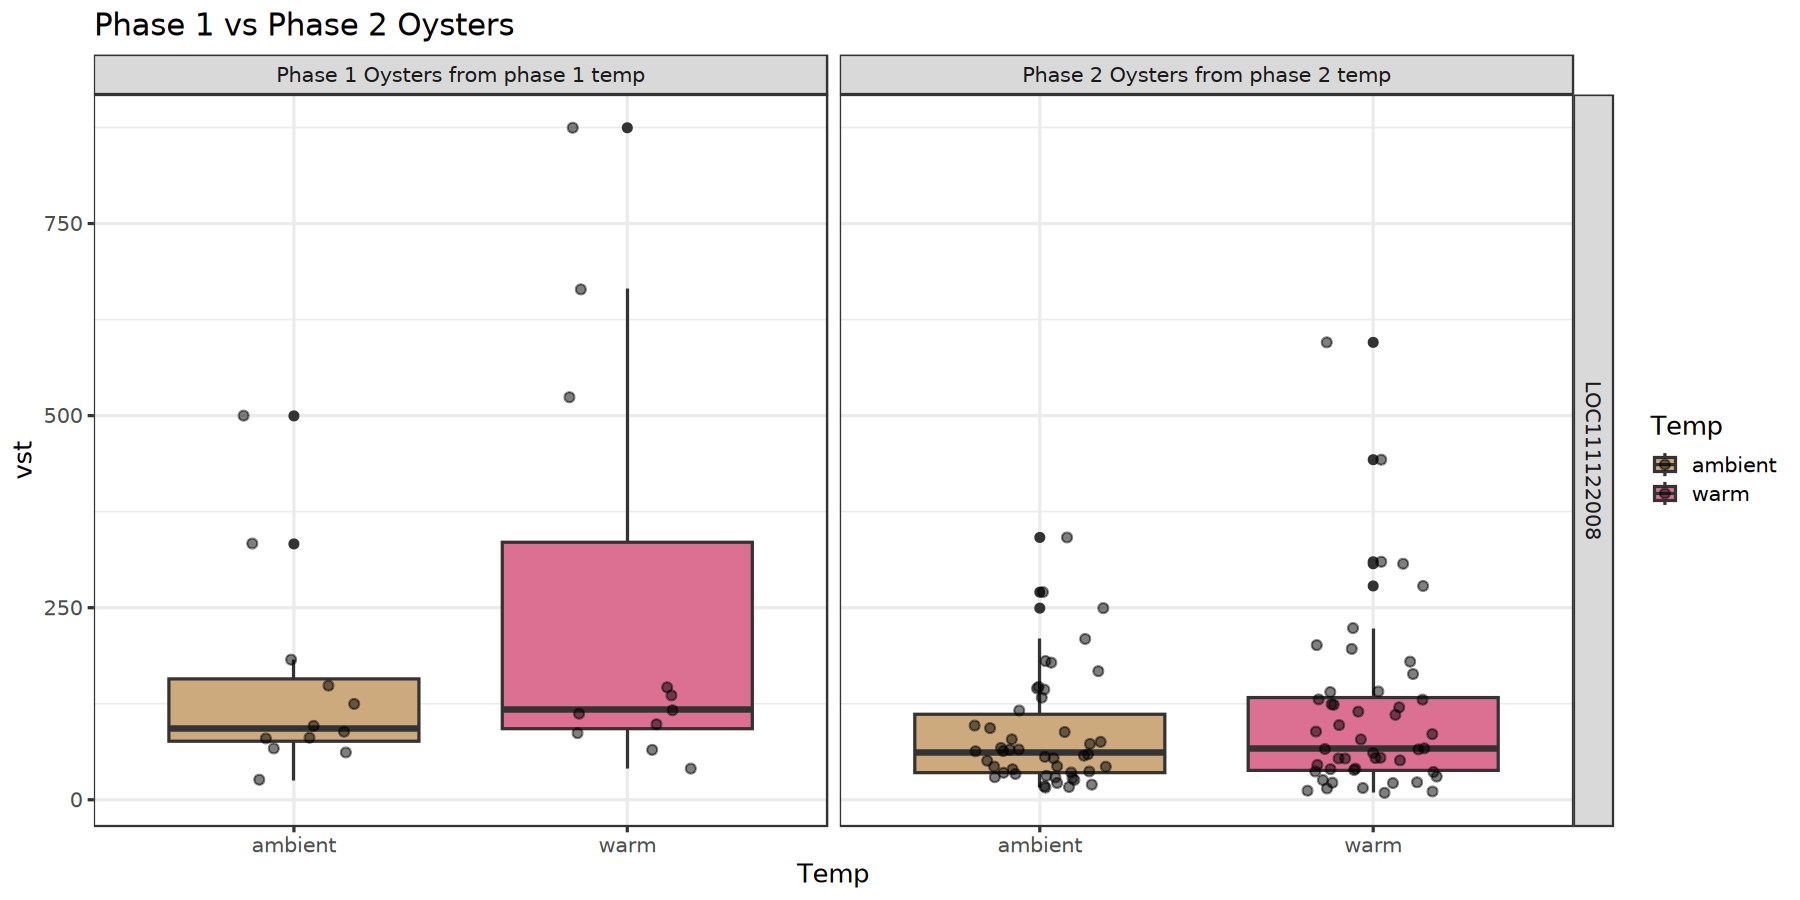

In [148]:
# Add phase labels and unify column name
p1 <- p1_oysters %>%
  mutate(Phase = "Phase 1 Oysters from phase 1 temp",
         Temp = Phase1_temp)

p2 <- p2_oysters %>%
  mutate(Phase = "Phase 2 Oysters from phase 2 temp",
         Temp = Phase2_temp)

combined <- bind_rows(p1, p2)

ggplot(combined, aes(x = Temp, y = vst, fill = Temp)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, alpha = 0.5) +
  facet_grid(Gene ~ Phase, scales = "free_y") +
scale_fill_manual(values = c("ambient" = "burlywood3", "warm" = "palevioletred")) + 
  labs(title = "Phase 1 vs Phase 2 Oysters") +
  theme_bw(base_size = 15)

(2 shared DEG in oysters sampled after phase 2 and due to second temp exposure and oysters sampeld after phase 1 due to first exposure temp)

interesting that we see a diff pattern - higher expression of these genes in control conditions for phase 1 oysters, but higher expression in phase 2 warming for phase 2 oysters (but overall, reduced expression of these genes in phase 2 oysters?)

#### 1 shared between P2 Phase 1 temp and P1 Phase 1 temp

In [20]:
p2_p1.temp[p2_p1.temp$Gene %in% p1_temp$X,-c(2:8)]

,Gene,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
25,LOC111117231,0.9375293,0,0,2.610162,0,0,0,0,0,⋯,1.084026,1.635231,0,0,0,0,0,0,0,0


- LOC111117231: uncharacterized

In [112]:
# this gets us the phase 2 oysters
p2_oysters <- p2_p1.temp[p2_p1.temp$Gene %in% p1_temp$X,-c(2:8)] %>%
  pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "vst"
  ) %>%
mutate(sample_from = 'phase 2')%>%
merge(meta, by = 'Sample')

# phase 1 oysters
p1_oysters <- p1_vst[p1_vst$Gene %in% p2_oysters$Gene,] %>%
pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "vst"
  ) %>%
mutate(sample_from = 'phase 1') %>%
merge(meta, by = 'Sample')

# combine dfs
#df1 <- rbind(p1_oysters, p2_oysters)
#df1 <- merge(df1, meta, by = 'Sample') %>%
#mutate(combo = paste(Phase1_treatment, Phase2_treatment))

head(p1_oysters)

,Sample,Gene,vst,sample_from,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_Nu_O03,LOC111117231,1.704847,phase 1,both,warm,hypoxic,1,NA,NA,NA,NA
2,B2_Nu_O12,LOC111117231,0.000000,phase 1,both,warm,hypoxic,2,NA,NA,NA,NA
3,B4_Nu_O32,LOC111117231,0.000000,phase 1,both,warm,hypoxic,4,NA,NA,NA,NA
4,B5_Nu_O36,LOC111117231,0.000000,phase 1,both,warm,hypoxic,5,NA,NA,NA,NA
5,B6_Nu_O47,LOC111117231,0.000000,phase 1,both,warm,hypoxic,6,NA,NA,NA,NA
6,C1_Nu_W01,LOC111117231,3.486674,phase 1,control,ambient,normoxic,1,NA,NA,NA,NA


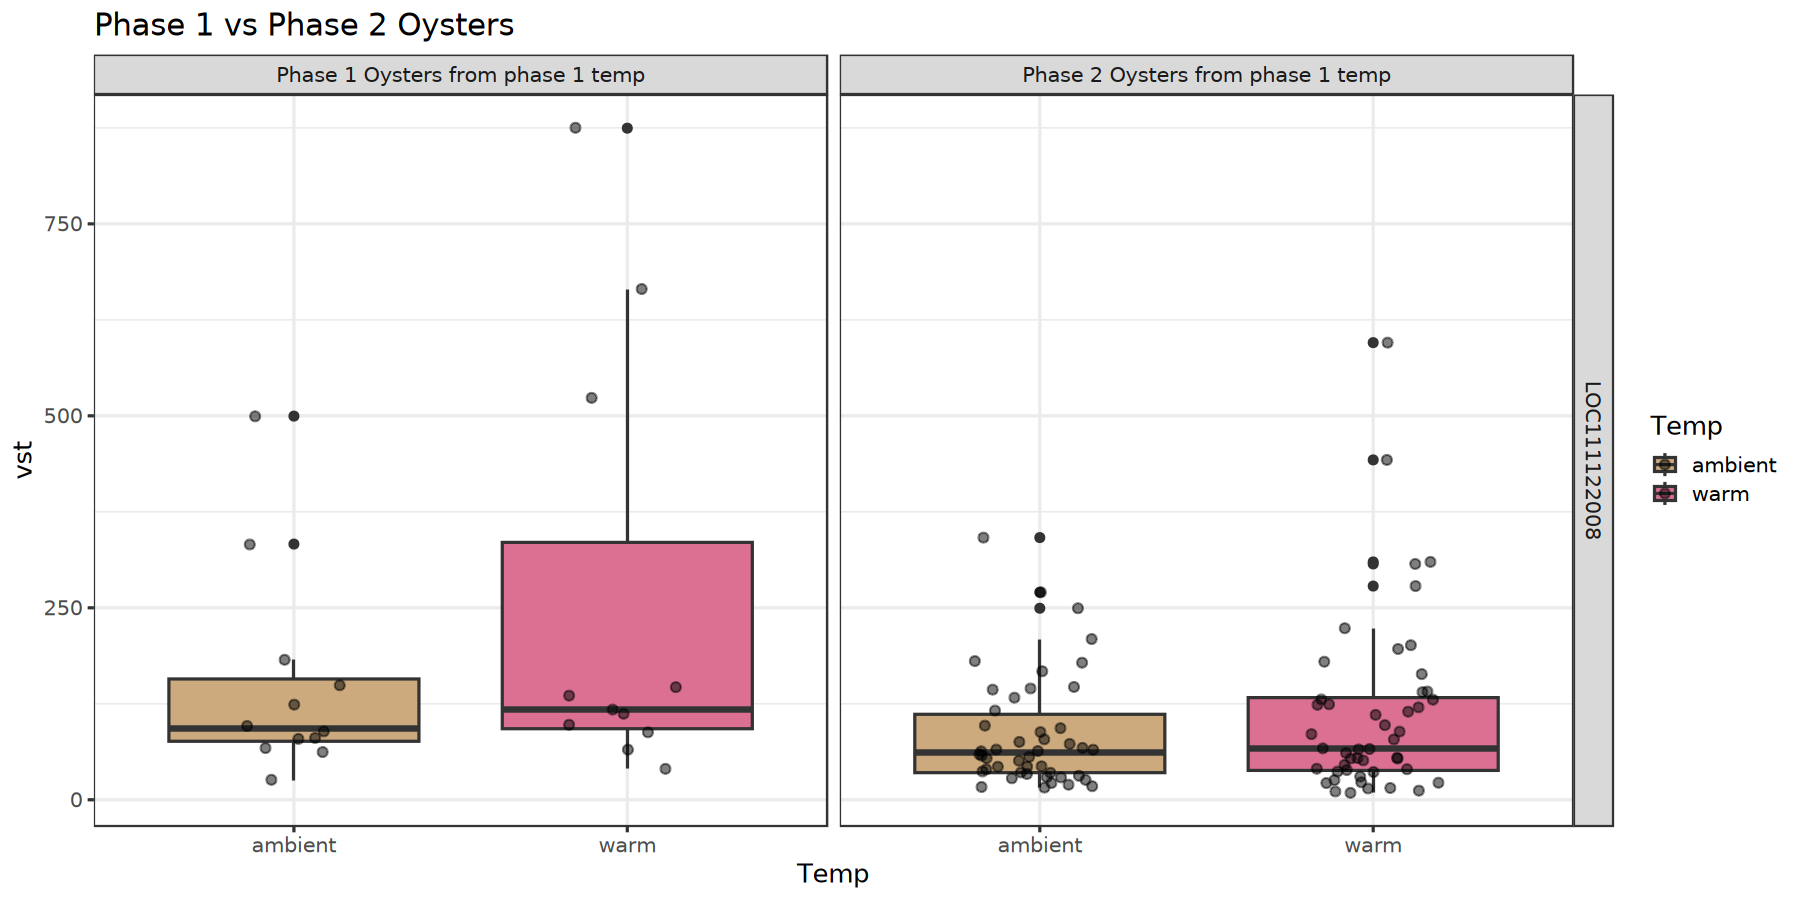

In [149]:
# Add phase labels and unify column name
p1 <- p1_oysters %>%
  mutate(Phase = "Phase 1 Oysters from phase 1 temp",
         Temp = Phase1_temp)

p2 <- p2_oysters %>%
  mutate(Phase = "Phase 2 Oysters from phase 1 temp",
         Temp = Phase2_temp)

combined <- bind_rows(p1, p2)

ggplot(combined, aes(x = Temp, y = vst, fill = Temp)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, alpha = 0.5) +
  facet_grid(Gene ~ Phase, scales = "free") +
scale_fill_manual(values = c("ambient" = "burlywood3", "warm" = "palevioletred")) + 
  labs(title = "Phase 1 vs Phase 2 Oysters") +
  theme_bw(base_size = 15)

(looking at the effect of phase 1 exposure but in oysters sampled after phase 1 (left) and after phase 2 (right))

significantly higher expression in phase 1 oysters exposed to warming, while reduced expression in phase 2 oysetrs in general - hard to tell what's going on in phase 2 oysters/likely has some context-dependent effects that are driving it to be a DEG in warm vs. ambient)

#### 2 shared between P2 Phase 1 temp and P2 Phase 2 temp

In [21]:
p2_p1.temp[p2_p1.temp$Gene %in% p2_p2.temp$Gene,-c(2:8)]

,Gene,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,LOC111130793,0.000000,3.977199,280.5878,1.740108,69.37752,1.175544,5.249574,0,0.00000,⋯,1180.505,0,3.731636,8.026369,0.9199066,21.10826,1788.77,2.216526,1.075999,792.6983
8,LOC111130777,1.875059,9.942998,317.4327,0.000000,1875.50558,17.633163,2.624787,0,4.38487,⋯,9446.205,0,2.487757,17.056035,5.5194397,41.16111,6437.27,11.082630,12.911988,6204.5112


- LOC111130793: uncharacterized
- LOC111130777: uncharacterized

In [153]:
# this gets us the phase 2 oysters
p1_temp_oys <- p2_p1.temp[p2_p1.temp$Gene %in% p2_p2.temp$Gene,-c(2:8)] %>%
  pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "vst"
  ) %>%
mutate(sample_from = 'phase 2')%>%
merge(meta, by = 'Sample')

head(p1_temp_oys)

,Sample,Gene,vst,sample_from,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_B1_O01,LOC111130793,0.000000,phase 2,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_B1_O01,LOC111130777,1.875059,phase 2,both,warm,hypoxic,1,both,warm,hypoxic,1
3,B1_W5_O50,LOC111130777,9.942998,phase 2,both,warm,hypoxic,1,warm,warm,normoxic,5
4,B1_W5_O50,LOC111130793,3.977199,phase 2,both,warm,hypoxic,1,warm,warm,normoxic,5
5,B2_B5_O51,LOC111130777,317.432656,phase 2,both,warm,hypoxic,2,both,warm,hypoxic,5
6,B2_B5_O51,LOC111130793,280.587794,phase 2,both,warm,hypoxic,2,both,warm,hypoxic,5


Warning message:
“Removed 11 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 41 rows containing missing values or values outside the scale range
(`geom_point()`).”


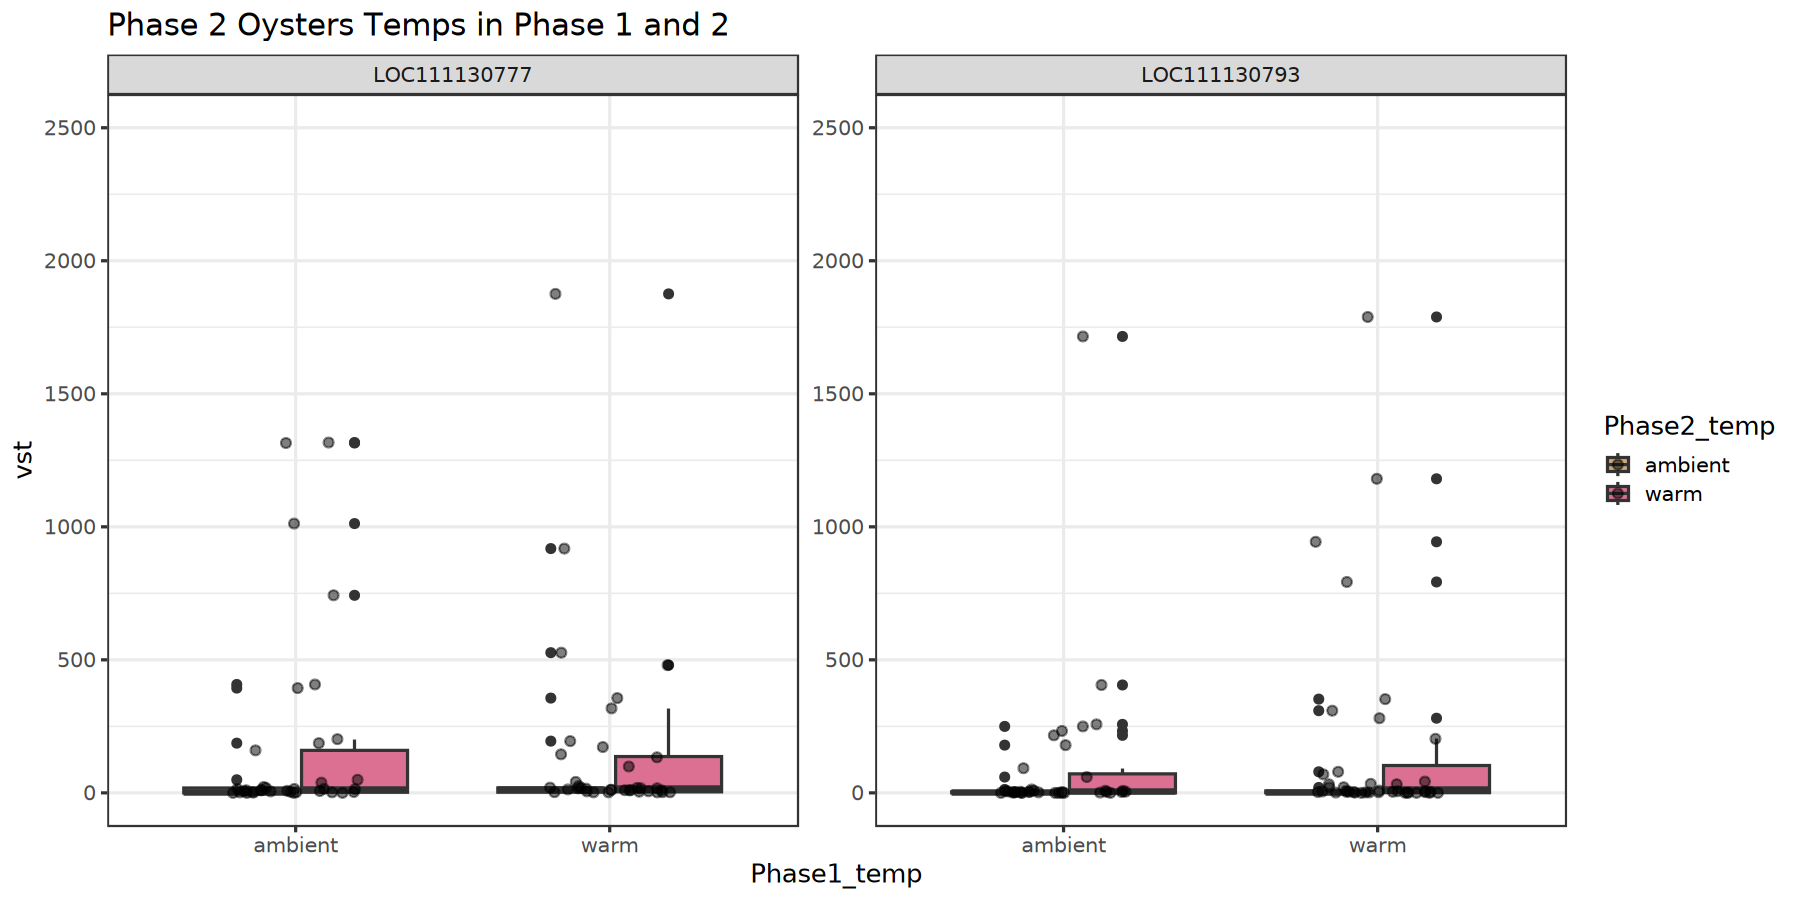

In [154]:
ggplot(p1_temp_oys, aes(x = Phase1_temp, y = vst, fill = Phase2_temp)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, alpha = 0.5) +
  facet_wrap(~Gene, scales = "free") +
  labs(title = "Phase 2 Oysters Temps in Phase 1 and 2") + 
scale_fill_manual(values = c("ambient" = "burlywood3", "warm" = "palevioletred")) + 
ylim(c(0,2500)) +
  theme_bw(base_size = 15)

so it looks like phase 2 temp is driving the differences in this - warming has higher expression of both of these genes (really regardless of phase 1 treatment)

### dissolved oxygen

#### 1 shared between P2 Phase 2 DO and P1 Phase 1 DO

In [155]:
p2_p2.DO[p2_p2.DO$Gene %in% p1_DO$X,-c(2:8)]

,Gene,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
8,LOC111122008,595.3311,36.78909,66.1318,57.42356,130.661,25.86197,78.74361,19.65772,36.17518,⋯,110.5707,14.71708,33.58473,65.21425,40.47589,45.38276,307.1392,75.36188,10.75999,78.63227


- LOC111122008: short transient receptor potential channel 7-like (protein binding, ion transport)

In [156]:
# this gets us the phase 2 oysters
p2_oysters <- p2_p2.DO[p2_p2.DO$Gene %in% p1_DO$X,-c(2:8)] %>%
  pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "vst"
  ) %>%
mutate(sample_from = 'phase 2')%>%
merge(meta, by = 'Sample')

# phase 1 oysters
p1_oysters <- p1_vst[p1_vst$Gene %in% p2_oysters$Gene,] %>%
pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "vst"
  ) %>%
mutate(sample_from = 'phase 1') %>%
merge(meta, by = 'Sample')

# combine dfs
#df1 <- rbind(p1_oysters, p2_oysters)
#df1 <- merge(df1, meta, by = 'Sample') %>%
#mutate(combo = paste(Phase1_treatment, Phase2_treatment))

head(p1_oysters)

,Sample,Gene,vst,sample_from,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_Nu_O03,LOC111122008,664.8903,phase 1,both,warm,hypoxic,1,NA,NA,NA,NA
2,B2_Nu_O12,LOC111122008,523.8754,phase 1,both,warm,hypoxic,2,NA,NA,NA,NA
3,B4_Nu_O32,LOC111122008,112.0889,phase 1,both,warm,hypoxic,4,NA,NA,NA,NA
4,B5_Nu_O36,LOC111122008,136.0980,phase 1,both,warm,hypoxic,5,NA,NA,NA,NA
5,B6_Nu_O47,LOC111122008,874.6103,phase 1,both,warm,hypoxic,6,NA,NA,NA,NA
6,C1_Nu_W01,LOC111122008,149.0553,phase 1,control,ambient,normoxic,1,NA,NA,NA,NA


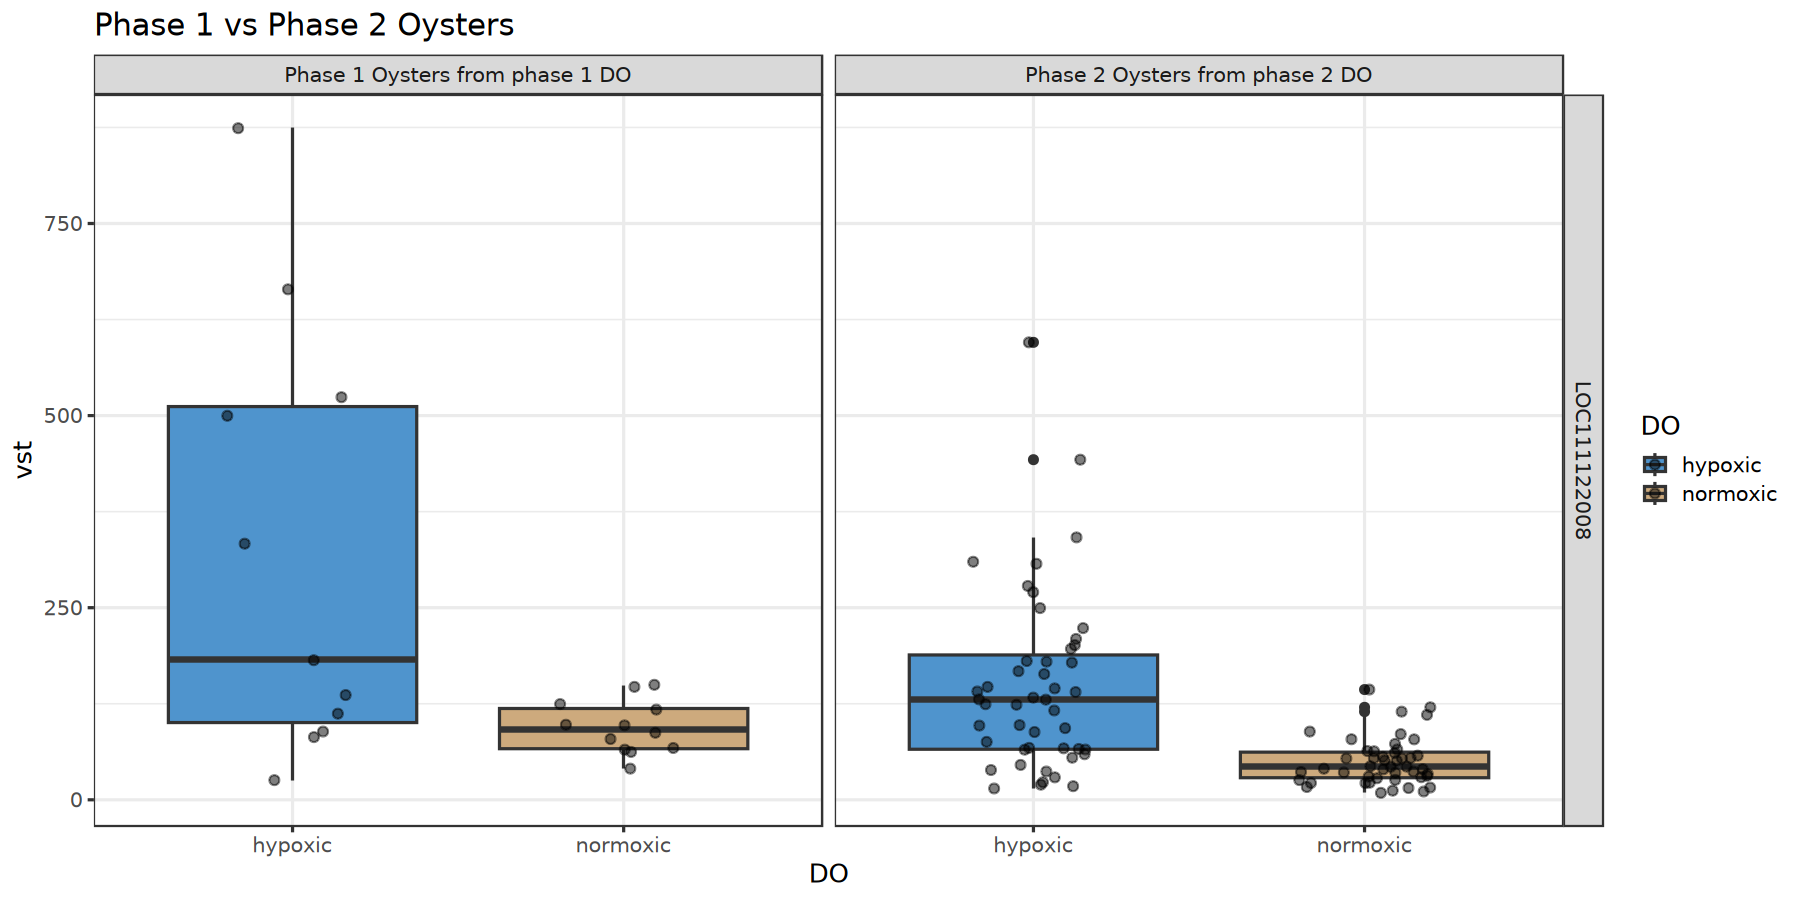

In [157]:
# Add phase labels and unify column name
p1 <- p1_oysters %>%
  mutate(Phase = "Phase 1 Oysters from phase 1 DO",
         DO = Phase1_DO)

p2 <- p2_oysters %>%
  mutate(Phase = "Phase 2 Oysters from phase 2 DO",
         DO = Phase2_DO)

combined <- bind_rows(p1, p2)

ggplot(combined, aes(x = DO, y = vst, fill = DO)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, alpha = 0.5) +
scale_fill_manual(values = c("normoxic" = "burlywood3", "hypoxic" = "steelblue3")) + 
  facet_grid(Gene ~ Phase, scales = "free_y") +
  labs(title = "Phase 1 vs Phase 2 Oysters") +
  theme_bw(base_size = 15)

(P2 Phase 2 DO and P1 Phase 1 DO)

higher expression in hypoxix conditions - although reduced expression in phase 2 oysters (frontloading!?)

#### 1 shared between P2 Phase 1 DO and P1 Phase 1 DO

In [23]:
p2_p1.DO[p2_p1.DO$Gene %in% p1_DO$X,-c(2:8)]

,Gene,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7,LOC111122631,14.06294,1.9886,2.83422,6.960431,612.8347,3.526633,1.312394,16.55387,789.2767,⋯,1.084026,0.8176153,3.731636,0,10.11897,0,9.202674,0,4.303996,0


- LOC111122631: uncharacterized 

#### 6 shared between P2 Phase 2 DO and P2 Phase 1 DO

In [24]:
p2_p2.DO[p2_p2.DO$Gene %in% p2_p1.DO$Gene,-c(2:8)]

,Gene,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
12,LOC111126857,71.252229,1.9885996,17.00532,17.401077,16.188088,3.526633,3.9371806,10.34617,7.673523,⋯,21.680526,0.000000,22.389817,1.003296,15.638413,0.000000,13.804010,6.649578,11.835989,9.563384
16,LOC111125091,10.312823,0.9942998,3.77896,0.000000,0.000000,0.000000,1.3123935,0.00000,0.000000,⋯,2.168053,4.905692,4.975515,38.125254,1.839813,0.000000,10.353008,445.521710,3.227997,7.438188
21,LOC111128079,0.000000,0.0000000,0.00000,5.220323,0.000000,0.000000,0.0000000,0.00000,2.192435,⋯,2.168053,4.905692,0.000000,0.000000,0.000000,0.000000,13.804010,4.433052,0.000000,0.000000
31,LOC111137992,5.625176,7.9543985,4.72370,1.740108,8.094044,8.228810,0.6561968,0.00000,0.000000,⋯,1163.160233,0.000000,0.000000,35.115366,3.679626,7.387891,318.642572,6.649578,5.379995,68.006288
43,LOC111102581,7.500235,3.9771993,6.61318,5.220323,48.564263,17.633163,61.6824955,0.00000,0.000000,⋯,276.426710,18.805152,12.438787,8.026369,0.000000,0.000000,904.162677,2.216526,9.683991,754.444755
60,LOC111114825,1.875059,190.9055649,22.67376,9.570593,33.532467,5.877721,14.4363287,13.45002,43.848704,⋯,20.596500,5.723307,0.000000,19.062627,1838.893335,7.387891,4.601337,17.732207,29.051972,1.062598


- LOC111126857: uncharacterized
- LOC111125091: von Willebrand factor D and EGF domain-containing protein-like (there was another vwf gene shared in temp above)
- LOC111128079: chitin synthase chs-2-like
- LOC111137992: tyrosinase-like protein (oxidoreductase activity)
      - tyrosinase - important role in periostracum formation (periostracum: uncalcified, cuticle layer covering the out surface of mollusk shell, plays significant role in shell biomineralization) - [paper](https://www-sciencedirect-com.umasslowell.idm.oclc.org/science/article/pii/S0006291X06002464?casa_token=P1Na5Hn61FoAAAAA:8zxz6gJIBDakAK24WX-yf1CNXIpqybBVJbR9EI3olDzuHBxhTL-Ap75Qosy_5H61gx6JARFC_vg) and [another paper looking at shell color in *C. gigas*](https://link-springer-com.umasslowell.idm.oclc.org/content/pdf/10.1007/s10126-021-10063-2.pdf)
- LOC111102581: leech-derived tryptase inhibitor C-like (enables protein binding)
- LOC111114825: uncharacterized

In [158]:
# this gets us the phase 2 oysters
p2_oys_do <- p2_p2.DO[p2_p2.DO$Gene %in% p2_p1.DO$Gene,-c(2:8)] %>%
  pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "vst"
  ) %>%
mutate(sample_from = 'phase 2')%>%
merge(meta, by = 'Sample')

head(p2_oys_do)

,Sample,Gene,vst,sample_from,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_B1_O01,LOC111126857,71.252229,phase 2,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_B1_O01,LOC111125091,10.312823,phase 2,both,warm,hypoxic,1,both,warm,hypoxic,1
3,B1_B1_O01,LOC111114825,1.875059,phase 2,both,warm,hypoxic,1,both,warm,hypoxic,1
4,B1_B1_O01,LOC111137992,5.625176,phase 2,both,warm,hypoxic,1,both,warm,hypoxic,1
5,B1_B1_O01,LOC111102581,7.500235,phase 2,both,warm,hypoxic,1,both,warm,hypoxic,1
6,B1_B1_O01,LOC111128079,0.000000,phase 2,both,warm,hypoxic,1,both,warm,hypoxic,1


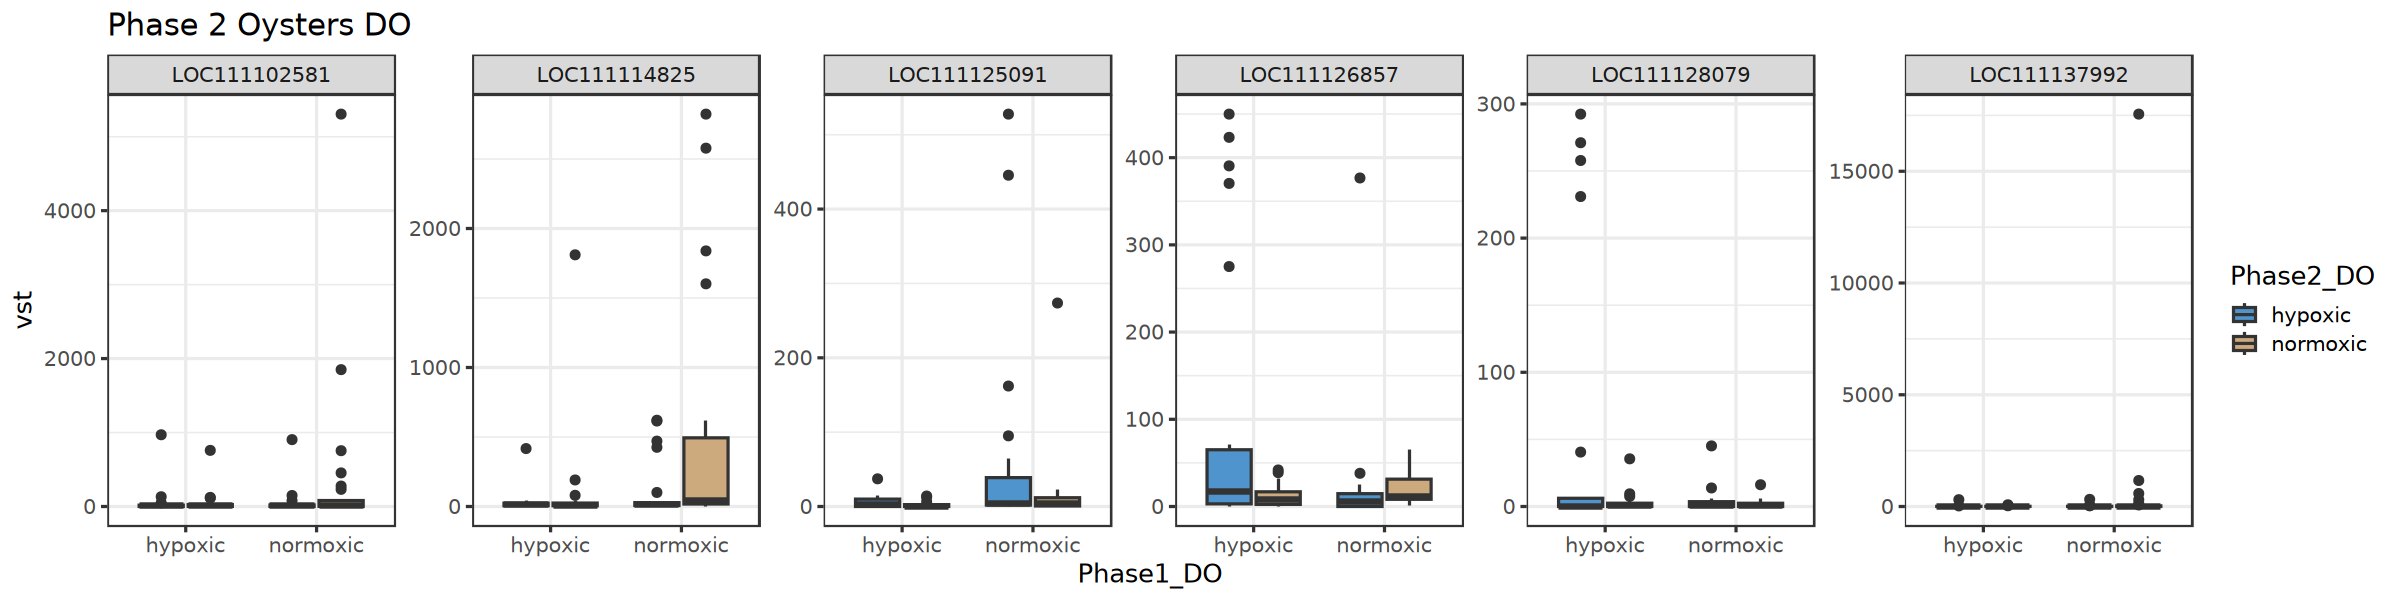

In [168]:
options(repr.plot.height = 5, repr.plot.width = 20)

ggplot(p2_oys_do, aes(x = Phase1_DO, y = vst, fill = Phase2_DO)) +
  geom_boxplot() +
  #geom_jitter(width = 0.1, alpha = 0.5) +
scale_fill_manual(values = c("normoxic" = "burlywood3", "hypoxic" = "steelblue3")) + 
  facet_wrap(~Gene, scales = "free", nrow = 1) +
  labs(title = "Phase 2 Oysters DO") +
  theme_bw(base_size = 15)

these 6 genes were identified as differentially expressed in phase 2 oysters when comparing phase 1 normoxia vs. hypoxia (x-axis) and comparing phase 2 normoxia vs. hypoxia (color)

- LOC111114825: differential expression was probably driven by phase 2 normoxia (appears to have higher expression? which prob drags the phase 1 DO value up for normoxia)
- LOC111125091: higher expression in phase 2 hypoxia (blue bars) than phase 1 hypoxia (left) - the normoxic-hypoxic group probably is driver of this DEG? (control or warm then hypoxic or both; so samples could be CH, CB, WH, WB)
- LOC111126857: 